In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import storage_model
importlib.reload(storage_model)
from storage_model import Storage

STORAGE /SWING MODEL:

In [2]:
# Read Forward Curve
curve = pd.DataFrame(pd.read_csv("curve.csv"))
curve['contractStart'] = pd.to_datetime(curve['contractStart'], format='mixed')
curve['contractEnd'] = pd.to_datetime(curve['contractEnd'], format='mixed')

In [4]:
quotes = pd.read_csv("quotes.csv")
quotes.columns = quotes.columns.str.strip()
quotes['valDate'] = pd.to_datetime(quotes['valDate'], format='mixed', dayfirst=True)
quotes['Start'] = pd.to_datetime(quotes['Start'], format='mixed', dayfirst=True)
quotes['End'] = pd.to_datetime(quotes['End'], format='mixed', dayfirst=True)
quotes

,Product,market,valDate,Start,End,N_days,bid,ask,notes
0,xxx,TTF,2026-01-01,2026-01-01,2026-12-31,120,1.45,1.78,NaN
1,xxx,TTF,2026-01-01,2026-10-01,2027-09-30,180,0.40,0.80,NaN
2,xxx,TTF,2026-01-01,2026-01-01,2026-06-30,90,0.40,0.80,NaN
3,xxx,TTF,2026-01-01,2026-04-01,2026-09-30,90,0.73,0.80,NaN
4,xxx,TTF,2026-01-01,2026-04-01,2026-10-31,90,0.90,1.05,NaN
5,xxx,TTF,2026-01-01,2027-10-01,2028-09-30,180,0.60,0.85,NaN


In [ ]:
quotes["model"] = 0.0
quotes["intrinsic"] = 0.0

for row in quotes.itertuples():

    valDate      = pd.Timestamp(row.valDate)
    storageStart = pd.Timestamp(row.Start)
    storageEnd   = pd.Timestamp(row.End)
    days         = int(row.N_days)

    s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=1000)
    s.build()
    flat_int = s.flat()
    print(f"flat = {s.flat():.2f}")


    # Intrinsic — start fully loaded
    s.set_volume_states(days)
    s.build()

    ProfiledEuro = s.v[0, 0, s.n_op_start]
    ACQ = np.sum(s.delta)

    intrinsic    = s.profiled() - flat_int
    print(f"Profiled price = {s.profiled():.2f}")
    print(f"Intrinsic Value  = {intrinsic:.2f} on top of flat price")


    # Extrinsic — full price tree
    s.n_p = 30
    s.build()

    FullValueEuro = s.v[0, s.n_p, s.n_op_start]
    print(f"Extrinsic price = {FullValueEuro / ACQ:.2f}")
    ExtrValue = (FullValueEuro - ProfiledEuro) / ACQ
    print(f"Extrinsic Value = {ExtrValue:.2f}")
    print("")

    quotes.loc[row.Index, "intrinsic"] = float(intrinsic)
    quotes.loc[row.Index, "model"]     = float(ExtrValue)

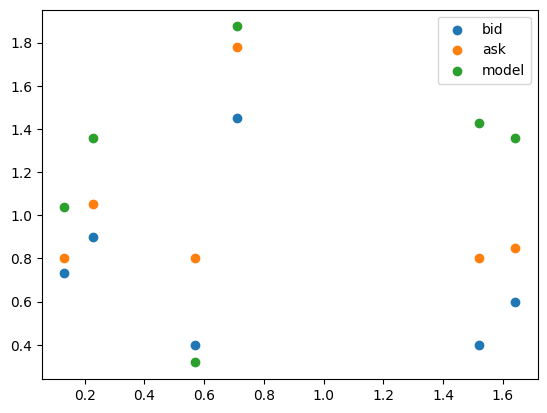

In [6]:
plt.scatter(quotes.intrinsic,quotes.bid,label='bid')
plt.scatter(quotes.intrinsic,quotes.ask,label='ask')
plt.scatter(quotes.intrinsic,quotes.model,label='model')
plt.legend()

Text(0.5, 1.0, 'Modelled Swing Premium vs Market Bids/Asks')

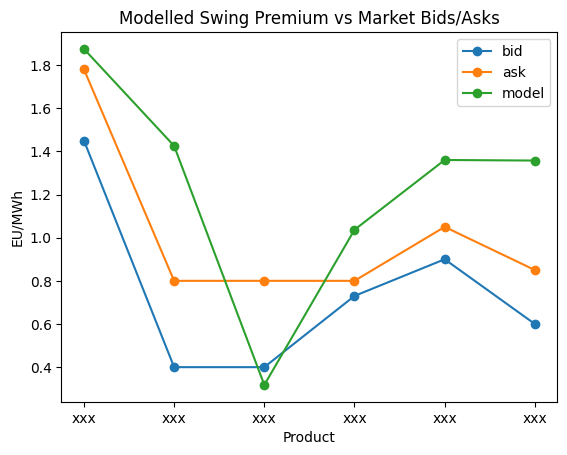

In [7]:
plt.plot(quotes.bid,'o-',label='bid')
plt.plot(quotes.ask,'o-',label='ask')
plt.plot(quotes.model,'o-',label='model')
plt.legend()
plt.xticks(ticks=range(len(quotes['Product'])), labels=quotes['Product'])
plt.ylabel("EU/MWh")
plt.xlabel("Product")
plt.title("Modelled Swing Premium vs Market Bids/Asks")

In [8]:

# Single swing: Jan-Dec 2025, 120 exercise days, 30% vol
valDate      = pd.Timestamp("2026-01-01")
storageStart = pd.Timestamp("2027-01-01")
storageEnd   = pd.Timestamp("2027-12-31")
days         = 120
vol          = 0.30

# Flat (no optionality baseline)
s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=1000, sVol=vol)
s.build()
flat_int = s.flat()
print(f"Flat price       = {flat_int:.2f}")

# Intrinsic — profiled, fully loaded at start
s.set_volume_states(days)
s.build()
ProfiledEuro = s.v[0, 0, s.n_op_start]
ACQ = np.sum(s.delta)
intrinsic = s.profiled() - flat_int
print(f"Profiled price   = {s.profiled():.2f}")
print(f"Intrinsic value  = {intrinsic:.2f}")

# Extrinsic — full price tree with 30% vol
s.n_p = 30
s.build()
FullValueEuro = s.v[0, s.n_p, s.n_op_start]
ExtrValue = (FullValueEuro - ProfiledEuro) / ACQ
print(f"Extrinsic price  = {FullValueEuro / ACQ:.2f}")
print(f"Extrinsic value  = {ExtrValue:.2f}")
print(f"Total swing value= {intrinsic + ExtrValue:.2f}")


Flat price       = 26.10
Profiled price   = 27.79
Intrinsic value  = 1.70
Extrinsic price  = 28.20
Extrinsic value  = 0.41
Total swing value= 2.11


In [9]:

# Put swing: Jan-Dec 2025, 120 exercise days, 30% vol
# Right to inject (BUY) gas — profits from choosing the cheapest days/scenarios
valDate      = pd.Timestamp("2026-01-01")
storageStart = pd.Timestamp("2027-01-01")
storageEnd   = pd.Timestamp("2027-12-31")
days         = 120
vol          = 0.30

# ── Flat baseline: must buy all year days, no timing choice ─────────────────
s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=1000, sVol=vol)
n = len(s.date_span)
s.i_curve = np.ones(n);  s.i_curve[s._active:] = 0.;  s.i_curve[:s.Dt] = 0.
s.w_curve = np.zeros(n)
full_cap     = s.n_op_start            # full-year exercise capacity
s.n_op_start = 0                       # start empty
s.t_p_curve  = np.full(s.n_op + 2, -1e9)
s.t_p_curve[full_cap] = 0.            # must buy all full_cap units by end
s.build()
flat_cost = s.flat()                   # average forward price over full year (EUR/MWh)
print(f"Flat cost        = {flat_cost:.2f}")

# ── Intrinsic: choose cheapest 'days' out of full year, no vol ──────────────
s.set_volume_states(days)              # n_op = days+1, states 0..days
s.n_op_start = 0                       # start empty
s.t_p_curve  = np.full(s.n_op + 2, -1e9)
s.t_p_curve[days] = 0.                # must buy exactly 'days' units
s.build()

ProfiledEuro  = s.v[0, 0, 0]
ACQ           = -np.sum(s.delta)      # positive: total volume bought
profiled_cost = s.profiled()          # average cost of cheapest 'days' forward prices
intrinsic     = flat_cost - profiled_cost
print(f"Profiled cost    = {profiled_cost:.2f}")
print(f"Intrinsic saving = {intrinsic:.2f}")

# ── Extrinsic: vol=30% lets you buy even cheaper on low-price realisations ──
s.n_p = 30
s.build()
FullValueEuro = s.v[0, s.n_p, 0]
ExtrValue     = (FullValueEuro - ProfiledEuro) / ACQ
print(f"Extrinsic saving = {ExtrValue:.2f}")
print(f"Total put swing  = {intrinsic + ExtrValue:.2f}")


Flat cost        = 26.10
Profiled cost    = 24.83
Intrinsic saving = 1.27
Extrinsic saving = 0.33
Total put swing  = 1.60


In [10]:

# Storage: 50 inj days / 60 wdr days, 0→0 volume, Jan-Dec 2025, 30% vol
# Buy low (inject), sell high (withdraw), start and end empty
valDate      = pd.Timestamp("2026-01-01")
storageStart = pd.Timestamp("2026-04-01")
storageEnd   = pd.Timestamp("2027-03-30")
inj_days     = 30
wdr_days     = 30
vol          = 0.30

s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=1000, sVol=vol)
n = len(s.date_span)

s.i_curve = np.ones(n);  s.i_curve[s._active:] = 0.;  s.i_curve[:s.Dt] = 0.
s.w_curve = np.ones(n);  s.w_curve[s._active:] = 0.;  s.w_curve[:s.Dt] = 0.
s.i_cost[:] = 0.5
s.w_cost[:] = 0.5

s.set_volume_states(inj_days)
s.n_op_start = 0
s.t_p_curve  = np.full(s.n_op + 2, -1e9)
s.t_p_curve[0] = 0.

max_vol = inj_days * s.v_step

# ── Intrinsic ────────────────────────────────────────────────────────────────
s.build()
intrinsic_eur = s.v[0, 0, 0]
intr_exp_ex   = np.array(s.exp_ex)

# ── Extrinsic ────────────────────────────────────────────────────────────────
s.n_p = 30
s.build()
total_eur = s.v[0, s.n_p, 0]
extr_eur  = total_eur - intrinsic_eur

print(f"Intrinsic value  = {intrinsic_eur:,.0f} EUR  ({intrinsic_eur/max_vol:.2f} EUR/MWh)")
print(f"Extrinsic value  = {extr_eur:,.0f} EUR  ({extr_eur/max_vol:.2f} EUR/MWh)")
print(f"Total value      = {total_eur:,.0f} EUR  ({total_eur/max_vol:.2f} EUR/MWh)")


Intrinsic value  = 27,404 EUR  (0.91 EUR/MWh)
Extrinsic value  = 22,949 EUR  (0.76 EUR/MWh)
Total value      = 50,354 EUR  (1.68 EUR/MWh)


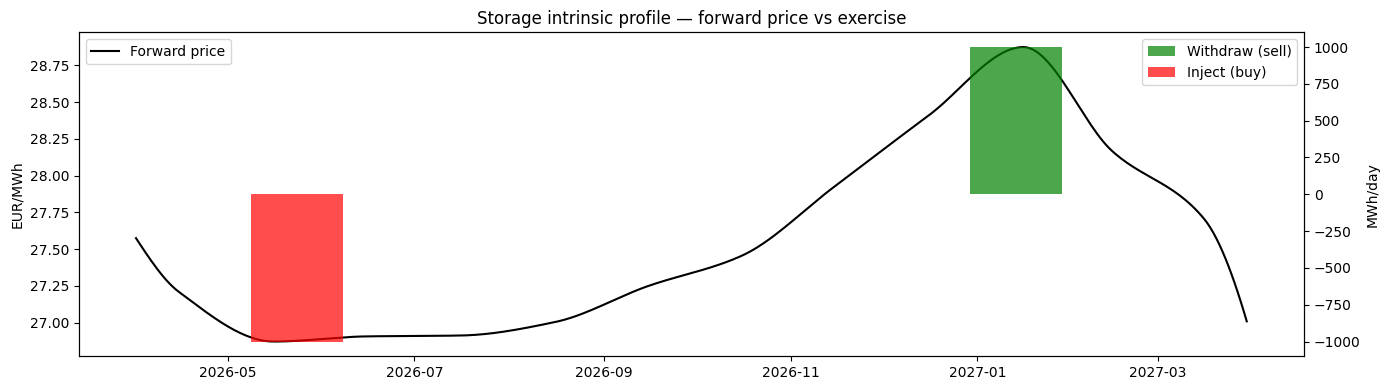

In [11]:

dates  = s.date_span[s.Dt:s._active]
prices = s.price_curve[s.Dt:s._active]
ex     = intr_exp_ex[s.Dt:s._active]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(dates, prices, 'k-', lw=1.5, label='Forward price')
ax2.bar(dates, np.where(ex > 0,  ex, 0), width=1, color='green', alpha=0.7, label='Withdraw (sell)')
ax2.bar(dates, np.where(ex < 0,  ex, 0), width=1, color='red',   alpha=0.7, label='Inject (buy)')

ax1.set_ylabel('EUR/MWh')
ax2.set_ylabel('MWh/day')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Storage intrinsic profile — forward price vs exercise')
plt.tight_layout()
plt.show()
